In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from scipy import sparse

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white")
sc.logging.print_header()

#OUTDIR = "../data/bench/lt/all/anndata"
OUTDIR = "../data/bench/tcr/anndata"
os.makedirs(OUTDIR, exist_ok=True)

COUNTS_FILE = "../data/bench/tcr/count.csv"
META_FILE = "../data/bench/tcr/meta.csv"

In [131]:
counts = pd.read_csv(COUNTS_FILE, header=0,index_col=0)
meta = pd.read_csv(META_FILE, header=0,index_col=0)

X = counts.values.T
X = sparse.csr_matrix(X)

adata = ad.AnnData(X=X, obs=meta)

adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 8365 × 16258
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.25', 'seurat_clusters', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.6', 'RNA_snn_res.0.8', 'RNA_snn_res.1', 'lineage', 'Dim_2', 'Dim_1', 'clonetype', 'ground_truth', 'fate_bias', 'truth_label'


In [132]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

normalizing counts per cell


    finished (0:00:00)


In [133]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat')
adata = adata[:, adata.var["highly_variable"]].copy()

extracting highly variable genes
    finished (0:00:00)


In [134]:
sc.pp.scale(adata)
sc.tl.pca(adata)

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption
computing PCA
    with n_comps=50
    finished (0:00:04)


computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:01)
computing UMAP
    finished (0:00:09)
running Leiden clustering
    finished (0:00:00)


<Axes: title={'center': 'lineage'}, xlabel='UMAP1', ylabel='UMAP2'>

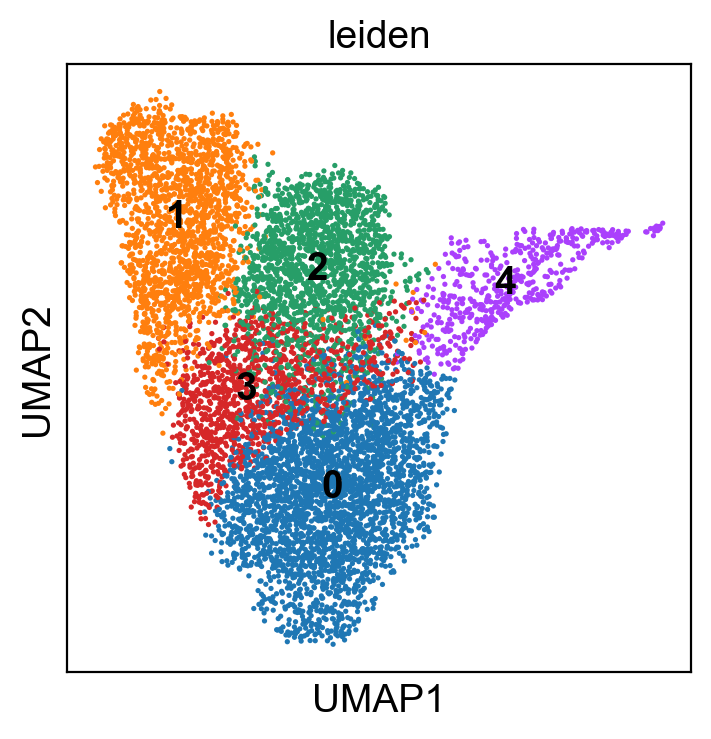

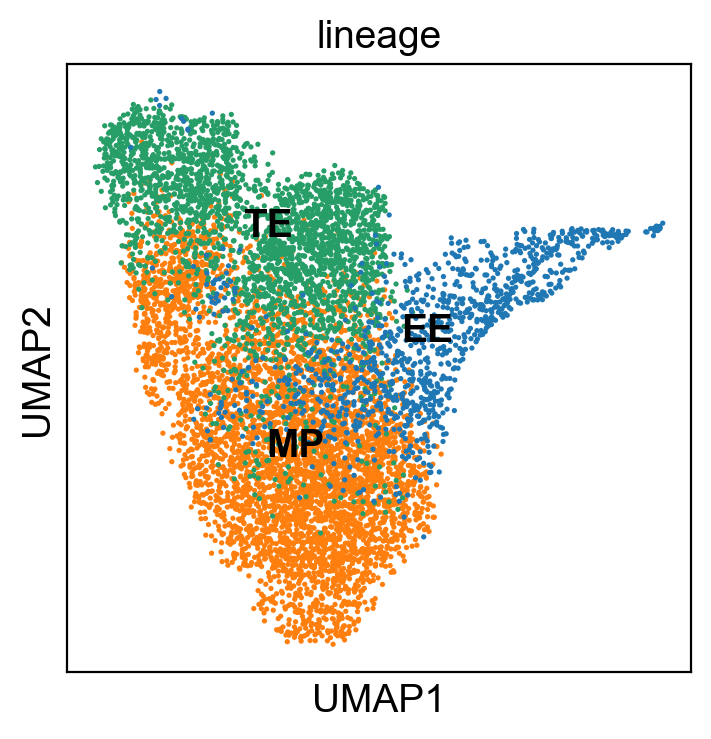

In [136]:
N_PCS = 30
N_NEIGHBORS = 30
LEIDEN_RES = 0.5

sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, n_pcs=N_PCS)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=LEIDEN_RES, key_added="leiden")

sc.pl.umap(adata, color=["leiden"], legend_loc="on data", show=False)
sc.pl.umap(adata, color=["lineage"], legend_loc="on data", show=False)

In [137]:
adata.obsm['X_emb'] = adata.obs[['Dim_1','Dim_2']].values

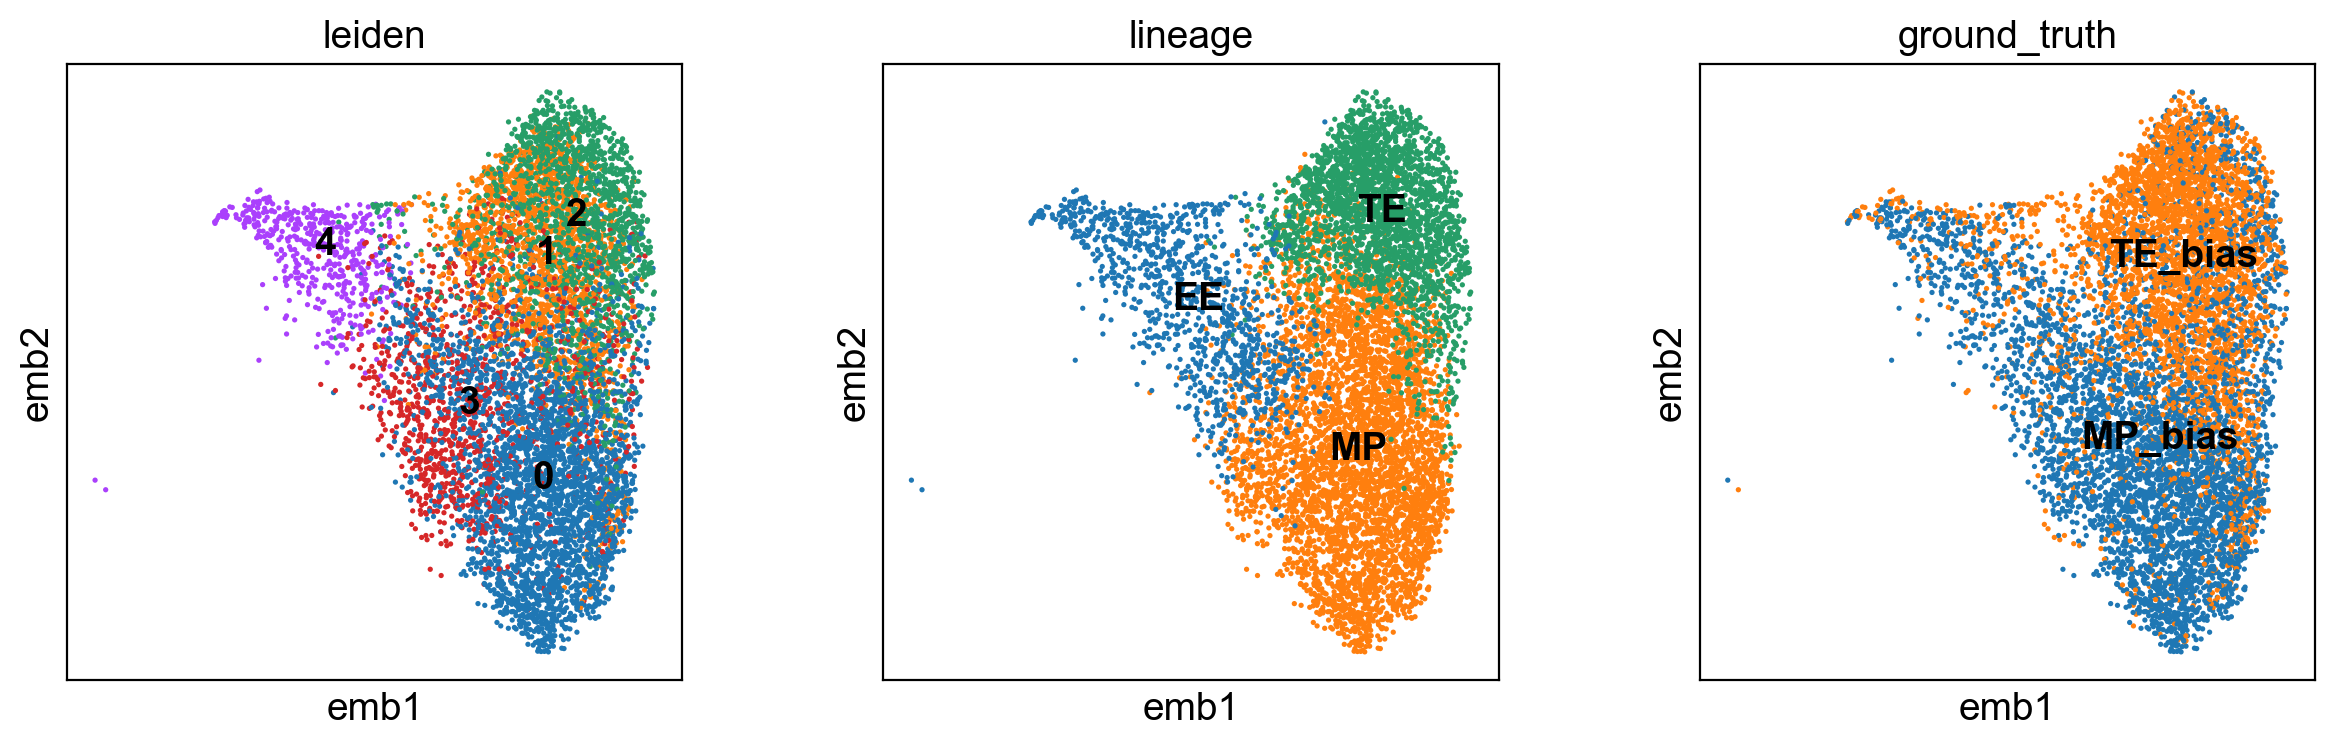

In [138]:
sc.pl.embedding(
    adata,
    basis="emb",
    color=["leiden", "lineage",'ground_truth'],
    legend_loc="on data",
)

In [141]:
adata.obs = adata.obs.loc[:, ['orig.ident','clonetype', "lineage", "fate_bias"]]

In [142]:
adata.write(os.path.join(OUTDIR, "lineage_tracing.h5ad"))